**Vulnerable App**

In [ ]:
%%writefile vulnerable_app.py
import hashlib

ADMIN_PASSWORD = "admin123"

password = input("Enter administrator password: ")

if password == ADMIN_PASSWORD:
  expression = input("Enter a calculation, for example 10 + 5: ")
  result = eval(expression)
  password_hash = hashlib.md5(password.encode()).hexdigest()
  print("Access granted. Password hash:", password_hash)
  print("Result:", result)
else:
  print("Access denied. Correct password is admin123")

Writing vulnerable_app.py


In [ ]:
%run vulnerable_app.py

Enter administrator password: admin123
Enter a calculation, for example 10 + 5: 10+3
Access granted. Password hash: 0192023a7bbd73250516f069df18b500
Result: 13


**Secure App**

In [ ]:
%%writefile secure_app.py
import os
import hmac
from getpass import getpass

stored_password = os.getenv("APP_ADMIN_PASSWORD")
if not stored_password:
    print("Application configuration error.")
    raise SystemExit(1)

entered_password = getpass("Enter administrator password: ")
if not hmac.compare_digest(entered_password, stored_password):
    print("Access denied.")
    raise SystemExit(1)

try:
    first = float(input("Enter the first number: "))
    operator = input("Enter an operator (+, -, *, /): ").strip()
    second = float(input("Enter the second number: "))

    operations = {
        "+": lambda a, b: a + b,
        "-": lambda a, b: a - b,
        "*": lambda a, b: a * b,
        "/": lambda a, b: a / b,
    }

    if operator not in operations:
        print("Invalid operator.")
    elif operator == "/" and second == 0:
        print("Division by zero is not allowed.")
    else:
        print("Result:", operations[operator](first, second))
except ValueError:
    print("Please enter valid numbers.")

Writing secure_app.py


In [ ]:
import os
os.environ["APP_ADMIN_PASSWORD"] = "pramitha123"


In [ ]:
%run secure_app.py

Enter administrator password: ··········
Enter the first number: 34
Enter an operator (+, -, *, /): /
Enter the second number: 4
Result: 8.5


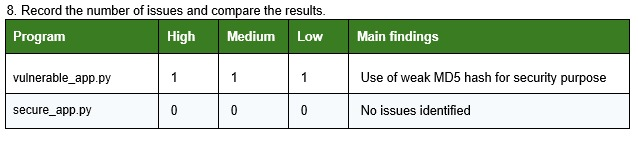

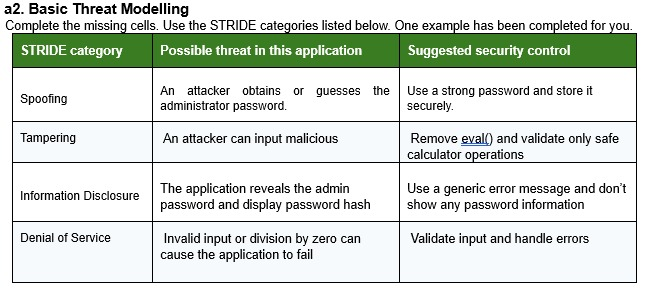

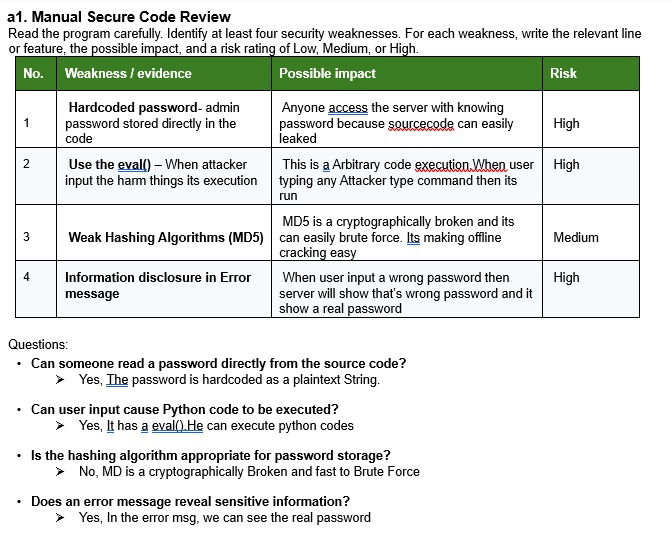